# 04 · Phân loại Phân khúc Giá Bất động sản

**Mục tiêu:** Phân loại bất động sản TP.HCM vào 5 phân khúc giá dựa trên Giá/m² .

| Nhãn | Mốc Giá/m² (triệu VNĐ) |
|---|---|
| 0 – Bình dân | < 35 |
| 1 – Trung cấp | 35 – < 60 |
| 2 – Cao cấp | 60 – < 120 |
| 3 – Hạng sang | 120 – 300 |
| 4 – Siêu sang | > 300 |

> Ngưỡng phân loại là **quy tắc nghiệp vụ cố định** (không học từ data),  
> đảm bảo tính giải thích được và tránh data leakage.

---

**Pipeline tổng quan:**
```
Processed CSVs
  └─ 3.4.1  Loại leakage columns
  └─ 3.4.2  Tạo nhãn phân loại (Giá/m²)
  └─ 3.4.3  StratifiedKFold CV (k=5) — so sánh 5 mô hình
  └─ 3.4.4  Huấn luyện mô hình tốt nhất trên full train
  └─ 3.4.5  Đánh giá trên test set (Report + Confusion Matrix)
  └─ 3.4.6  Feature Importance
  └─ 3.4.7  Lưu pipeline + kết luận
```

## 0 · Cài đặt & Import

In [1]:
# Cài thêm thư viện nếu chưa có
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

_ensure('imbalanced-learn', 'imblearn')
_ensure('xgboost')
print('✅ Thư viện sẵn sàng')

✅ Thư viện sẵn sàng


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, re, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.pipeline           import Pipeline
from sklearn.compose            import ColumnTransformer
from sklearn.impute             import SimpleImputer
from sklearn.preprocessing     import RobustScaler, OneHotEncoder
from sklearn.base               import clone
from sklearn.model_selection    import StratifiedKFold, cross_validate
from sklearn.metrics            import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm                import SVC

from imblearn.pipeline          import Pipeline as ImbPipeline
from imblearn.over_sampling     import SMOTENC

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('ℹ️  XGBoost không có — bỏ qua')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

print('✅ Import hoàn tất')
print(f'   numpy {np.__version__}  |  pandas {pd.__version__}')

✅ Import hoàn tất
   numpy 2.4.4  |  pandas 3.0.2


## 1 · Cấu hình đường dẫn

In [3]:
from pathlib import Path

PROJECT_ROOT  = Path.cwd().parent.parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "Processed"
OUTPUT_DIR    = PROCESSED_DIR / "ModelReady"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT  : {PROJECT_ROOT}')
print(f'PROCESSED_DIR : {PROCESSED_DIR}')
print(f'OUTPUT_DIR    : {OUTPUT_DIR}')

PROJECT_ROOT  : c:\Users\ADMIN\Tien_xu_ly_du_lieu_BDS
PROCESSED_DIR : c:\Users\ADMIN\Tien_xu_ly_du_lieu_BDS\data\Processed
OUTPUT_DIR    : c:\Users\ADMIN\Tien_xu_ly_du_lieu_BDS\data\Processed\ModelReady


## 2 · Load dữ liệu

In [4]:
X_train = pd.read_csv(PROCESSED_DIR / "Processed_data" / 'X_train_processed.csv', index_col=0)
y_train = pd.read_csv(PROCESSED_DIR / "Processed_data" / 'y_train_processed.csv', index_col=0).squeeze()
X_test  = pd.read_csv(PROCESSED_DIR / "Processed_data" / 'X_test_processed.csv',  index_col=0)
y_test  = pd.read_csv(PROCESSED_DIR / "Processed_data" /'y_test_processed.csv',  index_col=0).squeeze()

y_train = pd.Series(np.asarray(y_train).ravel(), index=X_train.index,
                    name='Khoảng giá', dtype=float)
y_test  = pd.Series(np.asarray(y_test).ravel(),  index=X_test.index,
                    name='Khoảng giá', dtype=float)

print('✅ Load thành công')
print(f'   X_train : {X_train.shape}  | y_train : {y_train.shape}')
print(f'   X_test  : {X_test.shape}   | y_test  : {y_test.shape}')

✅ Load thành công
   X_train : (2823, 25)  | y_train : (2823,)
   X_test  : (677, 25)   | y_test  : (677,)


## 3 · Chuẩn bị Features & Nhãn

### 3.1 · Loại cột gây Data Leakage

Bất kỳ cột phái sinh từ `Khoảng giá` (Giá/m², log-price, …)  
đều phải loại trước khi tạo nhãn để tránh mô hình "gian lận".

In [5]:
LEAKAGE_COLS = [
    'Khoảng giá', 'Giá', 'Giá/m2', 'Giá/m²', 'Gia_m2',
    'Giá trên m2', 'price_per_m2', 'price_per_m²',
    'Khoảng giá_log', 'Giá_log', 'Giá/m2_log', 'Giá_trên_m2',
    'Log_Khoảng_giá',
]

dropped = [c for c in LEAKAGE_COLS
           if c in X_train.columns or c in X_test.columns]
X_train.drop(columns=dropped, errors='ignore', inplace=True)
X_test.drop(columns=dropped,  errors='ignore', inplace=True)
print(f'Đã loại {len(dropped)} cột leakage: {dropped}')

# Chỉ giữ cột số — categorical đã được encode ở NB 03
X_train_model = X_train.select_dtypes(include='number').copy()
X_test_model  = X_test.select_dtypes(include='number').copy()

# Đồng bộ cột giữa train và test
X_train_model, X_test_model = X_train_model.align(
    X_test_model, join='left', axis=1, fill_value=np.nan
)

# Loại cột hằng số (zero variance)
const_cols = [c for c in X_train_model.columns
              if X_train_model[c].nunique(dropna=False) <= 1]
X_train_model.drop(columns=const_cols, inplace=True)
X_test_model.drop(columns=const_cols,  inplace=True)
if const_cols:
    print(f'Loại {len(const_cols)} cột hằng số: {const_cols}')

# Thay inf bằng NaN
X_train_model.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_model.replace([np.inf, -np.inf],  np.nan, inplace=True)

print(f'\n📐 Kích thước sau khi lọc:')
print(f'   X_train_model : {X_train_model.shape}')
print(f'   X_test_model  : {X_test_model.shape}')
print(f'\nCác đặc trưng ({X_train_model.shape[1]} cột):')
print(list(X_train_model.columns))

Đã loại 0 cột leakage: []

📐 Kích thước sau khi lọc:
   X_train_model : (2823, 18)
   X_test_model  : (677, 18)

Các đặc trưng (18 cột):
['Diện tích', 'Số tầng', 'Đường vào', 'Loại đường vào', 'loai_duong_null_flag', 'duong_vao_null_flag', 'hem_xe_hoi', 'gan_cho_sieu_thi', 'gan_truong_hoc', 'gan_benh_vien', 'gan_cong_vien_ho_nuoc', 'Tổng số phòng', 'Pháp lý_Sổ đỏ', 'Pháp lý_không có', 'Nội thất_Cơ bản', 'Nội thất_Trống / Nhà thô', 'Nội thất_Đầy đủ', 'Quận_encoded']


### 3.2 · Tạo nhãn phân loại theo K means


In [6]:
LABELS    = ['Bình dân', 'Trung cấp', 'Cao cấp', 'Hạng sang', 'Siêu sang']
LABEL_MAP = {l: i for i, l in enumerate(LABELS)}

# Khởi tạo và tính toán gia_m2_train, gia_m2_test
area_train = pd.to_numeric(X_train['Diện tích'], errors='coerce')
area_test  = pd.to_numeric(X_test['Diện tích'],  errors='coerce')

valid_tr = y_train.notna() & area_train.notna() & (area_train > 0)
valid_te = y_test.notna()  & area_test.notna()  & (area_test  > 0)

gia_m2_train = (y_train.loc[valid_tr] * 1000) / area_train.loc[valid_tr]
gia_m2_test  = (y_test.loc[valid_te] * 1000)  / area_test.loc[valid_te]

# Lọc ngoại lai 1% trên tập huấn luyện
nguong_99 = np.percentile(gia_m2_train.dropna(), 99)
gia_m2_train_filtered = gia_m2_train[gia_m2_train <= nguong_99]

# Thực thi K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(gia_m2_train_filtered.values.reshape(-1, 1))

# Xác định ranh giới
df_kmeans = pd.DataFrame({'gia_m2': gia_m2_train_filtered.values, 'cluster': clusters})
cluster_max_vals = df_kmeans.groupby('cluster')['gia_m2'].max().sort_values().values
BREAKS = [0] + cluster_max_vals[:-1].tolist() + [np.inf]

def assign_segment(price_series):
    labels_arr = pd.cut(price_series, bins=BREAKS, labels=LABELS, right=True)
    return labels_arr.cat.set_categories(LABELS, ordered=True)

# Ghi đè trực tiếp lên biến hiện tại
y_train_class = assign_segment(gia_m2_train)
y_test_class  = assign_segment(gia_m2_test)

# LƯU Ý 1: Bỏ .astype('int64') ở bước này. 
# Nếu dữ liệu có NaN, ép kiểu int64 ngay lập tức sẽ gây lỗi ValueError.
y_train_enc   = y_train_class.map(LABEL_MAP)
y_test_enc    = y_test_class.map(LABEL_MAP)

valid_label_tr = y_train_enc.notna()
valid_label_te = y_test_enc.notna()

# LƯU Ý 2: Cập nhật trực tiếp DataFrame (Đã sửa lỗi IndexingError)
X_train_model = X_train_model.loc[valid_label_tr[valid_label_tr].index]
X_test_model  = X_test_model.loc[valid_label_te[valid_label_te].index]

# Lúc này dữ liệu đã sạch NaN, ta mới an toàn ép kiểu về int64
y_train_enc   = y_train_enc.loc[valid_label_tr].astype('int64')
y_test_enc    = y_test_enc.loc[valid_label_te].astype('int64')

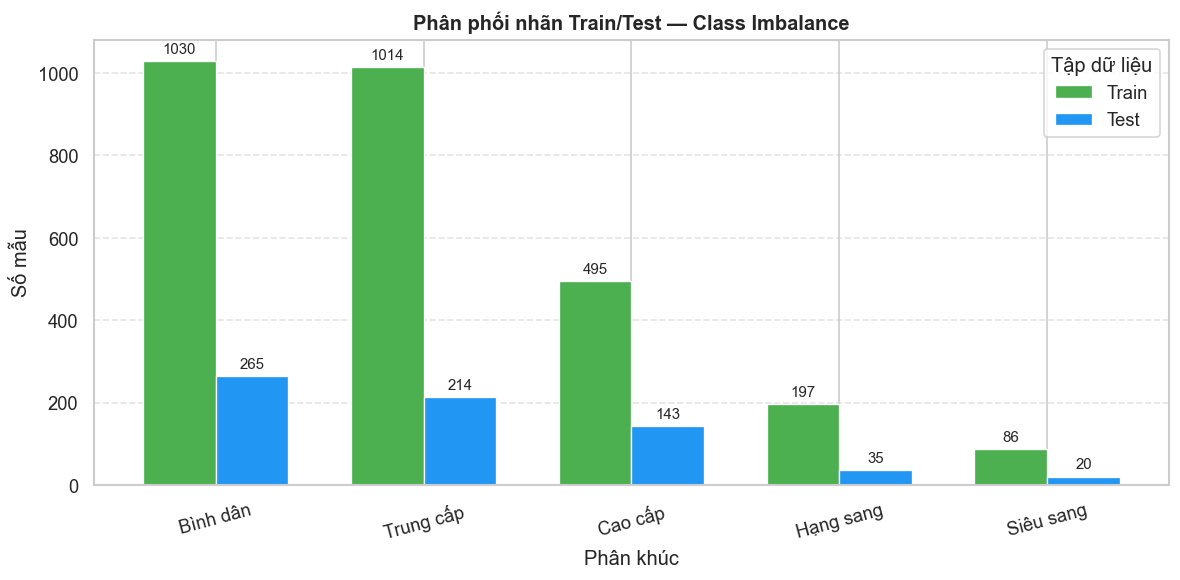

📊 Biểu đồ đã lưu: class_distribution.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Tính toán số lượng đếm cho từng tập (bảo đảm thứ tự nhãn giống nhau)
train_counts = y_train_enc.value_counts().sort_index()
test_counts = y_test_enc.value_counts().sort_index()

# Lấy ra giá trị thực tế theo thứ tự của LABELS
# (Tránh lỗi nếu có nhãn nào đó số lượng bằng 0)
train_values = [train_counts.get(i, 0) for i in range(len(LABELS))]
test_values = [test_counts.get(i, 0) for i in range(len(LABELS))]

# 3. Tính toán vị trí và độ rộng của cột
x = np.arange(len(LABELS))  # Mảng vị trí gốc: [0, 1, 2, 3, 4]
width = 0.35                # Độ rộng của mỗi cột

# 4. Vẽ cột
# Dịch Train sang trái (x - width/2), dịch Test sang phải (x + width/2)
rects_train = ax.bar(x - width/2, train_values, width, 
                     label='Train', color='#4CAF50', edgecolor='white', linewidth=0.8)
rects_test = ax.bar(x + width/2, test_values, width, 
                    label='Test', color='#2196F3', edgecolor='white', linewidth=0.8)

# 5. Thiết lập nhãn dán, tiêu đề và lưới
ax.set_title('Phân phối nhãn Train/Test — Class Imbalance', fontweight='bold', fontsize=12)
ax.set_xlabel('Phân khúc')
ax.set_ylabel('Số mẫu')

# Cập nhật tên các nhãn trên trục X vào đúng vị trí trung tâm
ax.set_xticks(x)
ax.set_xticklabels(LABELS, rotation=15)

# Thêm chú giải (legend)
ax.legend(title='Tập dữ liệu')

# Thêm đường lưới ngang để dễ gióng số lượng
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 6. Hiển thị số lượng trực tiếp trên đỉnh mỗi cột
ax.bar_label(rects_train, padding=3, fontsize=9)
ax.bar_label(rects_test, padding=3, fontsize=9)

# 7. Căn chỉnh và lưu file
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', bbox_inches='tight')
plt.show()

print('📊 Biểu đồ đã lưu: class_distribution.png')

In [8]:
X_train_model.shape

(2822, 18)

In [9]:
X_train_model.columns

Index(['Diện tích', 'Số tầng', 'Đường vào', 'Loại đường vào',
       'loai_duong_null_flag', 'duong_vao_null_flag', 'hem_xe_hoi',
       'gan_cho_sieu_thi', 'gan_truong_hoc', 'gan_benh_vien',
       'gan_cong_vien_ho_nuoc', 'Tổng số phòng', 'Pháp lý_Sổ đỏ',
       'Pháp lý_không có', 'Nội thất_Cơ bản', 'Nội thất_Trống / Nhà thô',
       'Nội thất_Đầy đủ', 'Quận_encoded'],
      dtype='str')

## 4 · Định nghĩa Pipeline Tiền xử lý + Mô hình

In [10]:
# ── Xác định cột ──────────────────────────────────────────────────────────
numeric_cols     = X_train_model.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train_model.select_dtypes(exclude='number').columns.tolist()

# OHE columns từ NB03 nằm trong numeric_cols (đã là 0/1 float).
# Cần đánh dấu chúng để SMOTENC biết xử lý đúng.
OHE_PREFIXES = ('Pháp lý_', 'Nội thất_')
ohe_col_indices = [
    i for i, col in enumerate(numeric_cols)
    if col.startswith(OHE_PREFIXES)
]
print(f'Số cột OHE binary trong X_train_model : {len(ohe_col_indices)}')
print(f'  → {[numeric_cols[i] for i in ohe_col_indices]}')

# ── Preprocessor (chỉ numeric pipeline vì categorical đã encode ở NB03) ──
num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', RobustScaler()),
])

transformers = [('num', num_pipe, numeric_cols)]
if categorical_cols:                          # phòng trường hợp còn sót
    cat_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    transformers.append(('cat', cat_pipe, categorical_cols))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

# ── Models: dùng class_weight='balanced' cho học nhạy cảm chi phí ─────────
# XGBoost dùng compute_sample_weight thay thế (xử lý riêng tại Section 6).
# Cấu hình các mô hình với siêu tham số chống Overfitting và Học nhạy cảm chi phí
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=5000, class_weight='balanced', random_state=42),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5, 
        class_weight='balanced', random_state=42, n_jobs=-1),
    
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5, 
        class_weight='balanced', random_state=42, n_jobs=-1),
    
    'SVM RBF': SVC(
        kernel='rbf', C=10, gamma='scale', 
        class_weight='balanced', random_state=42),
    
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.03, max_depth=4, 
        subsample=0.8, colsample_bytree=0.8, 
        objective='multi:softprob', eval_metric='mlogloss',
        tree_method='hist', random_state=42, n_jobs=2, verbosity=0)
}

def build_pipeline(estimator):
    # Truyền trực tiếp đối tượng, không gọi hàm clone
    return Pipeline([
        ('pre', preprocessor),
        ('clf', estimator),
    ])

print(f'\nSẽ huấn luyện {len(MODELS)} mô hình:')
for name in MODELS:
    print(f'  • {name}')


Số cột OHE binary trong X_train_model : 5
  → ['Pháp lý_Sổ đỏ', 'Pháp lý_không có', 'Nội thất_Cơ bản', 'Nội thất_Trống / Nhà thô', 'Nội thất_Đầy đủ']

Sẽ huấn luyện 5 mô hình:
  • Logistic Regression
  • Random Forest
  • Extra Trees
  • SVM RBF
  • XGBoost


## 5 · StratifiedKFold Cross-Validation (k=5)

Cross-validation cho phép đánh giá **độ ổn định** của mô hình trên nhiều fold,  
không phụ thuộc vào một lần chia train/test cụ thể.

> **Lưu ý:** SMOTE chỉ được áp dụng bên trong mỗi fold train —  
> fold validation luôn giữ nguyên để tránh data leakage.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = {'macro_f1': 'f1_macro', 'accuracy': 'accuracy', 'weighted_f1': 'f1_weighted'}
cv_results = []

for name, estimator in MODELS.items():
    pipe = build_pipeline(estimator)
    
    fit_params = {}
    if name == 'XGBoost':
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)
        fit_params = {'clf__sample_weight': sample_weights}

    scores = cross_validate(pipe, X_train_model, y_train_enc, cv=CV, scoring=SCORING, 
                            n_jobs=-1, return_train_score=False, params=fit_params)
    
    cv_results.append({
        'Mô hình'        : name,
        'Macro F1 (mean)': scores['test_macro_f1'].mean(),
        'Macro F1 (std)' : scores['test_macro_f1'].std(),
        'Accuracy (mean)': scores['test_accuracy'].mean(),
        'Accuracy (std)' : scores['test_accuracy'].std(),
        'W-F1 (mean)'    : scores['test_weighted_f1'].mean(),
        'W-F1 (std)'     : scores['test_weighted_f1'].std(),
        '_raw_macro_f1'  : scores['test_macro_f1'],  # dùng cho boxplot
    })

cv_df = pd.DataFrame(cv_results)
print(f'✅ CV hoàn tất — {len(cv_results)} mô hình')


✅ CV hoàn tất — 5 mô hình


In [12]:
# ── Bảng so sánh ──────────────────────────────────────────────────────────
cv_df = (
    pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                  for r in cv_results])
    .sort_values('Macro F1 (mean)', ascending=False)
    .reset_index(drop=True)
)

fmt_cols = [c for c in cv_df.columns if c != 'Mô hình']
display(
    cv_df.style
    .format({c: '{:.4f}' for c in fmt_cols})
    .bar(subset=['Macro F1 (mean)'], color='#90CAF9')
    .set_caption('Kết quả StratifiedKFold CV (k=5)')
)

BEST = cv_df.loc[0, 'Mô hình']
print(f'\n🏆 Mô hình tốt nhất theo Macro F1 (CV): {BEST}')

,Mô hình,Macro F1 (mean),Macro F1 (std),Accuracy (mean),Accuracy (std),W-F1 (mean),W-F1 (std)
0,XGBoost,0.5909,0.0221,0.6432,0.0260,0.6455,0.0260
1,Random Forest,0.5559,0.0169,0.6130,0.0066,0.6153,0.0081
2,SVM RBF,0.5149,0.0184,0.5854,0.0100,0.5890,0.0098
3,Logistic Regression,0.4808,0.0259,0.5564,0.0177,0.5544,0.0175
4,Extra Trees,0.4732,0.0137,0.5503,0.0153,0.5445,0.0166



🏆 Mô hình tốt nhất theo Macro F1 (CV): XGBoost


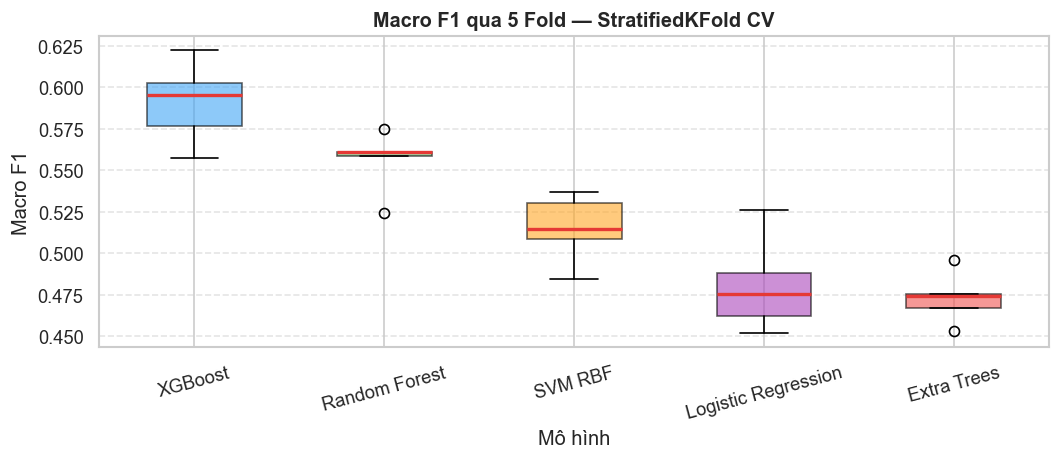

📊 Đã lưu: cv_macro_f1_boxplot.png


In [13]:
# ── Visualize: Boxplot Macro F1 theo từng fold ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

order = cv_df['Mô hình'].tolist()           # thứ tự đã sort theo mean
box_data = [next(r['_raw_macro_f1'] for r in cv_results
                 if r['Mô hình'] == name)
            for name in order]

bp = ax.boxplot(box_data, tick_labels=order,
                patch_artist=True, widths=0.5,
                medianprops=dict(color='#E53935', linewidth=2))

palette = ['#42A5F5','#66BB6A','#FFA726','#AB47BC','#EF5350']
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title('Macro F1 qua 5 Fold — StratifiedKFold CV',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Mô hình')
ax.set_ylabel('Macro F1')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_macro_f1_boxplot.png', bbox_inches='tight')
plt.show()
print('📊 Đã lưu: cv_macro_f1_boxplot.png')

## 6 · Huấn luyện mô hình tốt nhất trên Full Train Set

In [14]:
print(f'Đang huấn luyện {BEST} trên toàn bộ tập Train...')
best_pipe = build_pipeline(MODELS[BEST])
if BEST == 'XGBoost':
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)
    best_pipe.fit(X_train_model, y_train_enc, clf__sample_weight=sample_weights)
else:
    best_pipe.fit(X_train_model, y_train_enc)
print('✅ Huấn luyện hoàn tất')


Đang huấn luyện XGBoost trên toàn bộ tập Train...
✅ Huấn luyện hoàn tất


## 7 · Đánh giá trên Test Set

> Chỉ chạy **một lần** trên test set sau khi đã chọn mô hình bằng CV.

In [15]:
y_pred = best_pipe.predict(X_test_model)

test_acc  = accuracy_score(y_test_enc, y_pred)
test_mf1  = f1_score(y_test_enc, y_pred, average='macro',    zero_division=0)
test_wf1  = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)

print('=' * 55)
print(f'  KẾT QUẢ TRÊN TEST SET — {BEST}')
print('=' * 55)
print(f'  Accuracy    : {test_acc:.4f}')
print(f'  Macro F1    : {test_mf1:.4f}')
print(f'  Weighted F1 : {test_wf1:.4f}')
print('=' * 55)

best_cv_row = cv_df.loc[cv_df['Mô hình'] == BEST].iloc[0]
print(f'\n  CV Macro F1 (mean ± std) : '
      f'{best_cv_row["Macro F1 (mean)"]:.4f} ± {best_cv_row["Macro F1 (std)"]:.4f}')
gap = abs(test_mf1 - best_cv_row['Macro F1 (mean)'])
print(f'  |CV mean − Test|        : {gap:.4f}',
      '← ổn' if gap < 0.05 else '← kiểm tra lại, khoảng cách lớn')

  KẾT QUẢ TRÊN TEST SET — XGBoost
  Accuracy    : 0.6514
  Macro F1    : 0.5975
  Weighted F1 : 0.6544

  CV Macro F1 (mean ± std) : 0.5909 ± 0.0221
  |CV mean − Test|        : 0.0066 ← ổn


In [16]:
# ── Classification Report per class ──────────────────────────────────────
print(f'\nClassification Report — {BEST}\n')
print(classification_report(
    y_test_enc, y_pred,
    labels=list(range(len(LABELS))),
    target_names=LABELS,
    zero_division=0,
))


Classification Report — XGBoost

              precision    recall  f1-score   support

    Bình dân       0.80      0.80      0.80       265
   Trung cấp       0.59      0.57      0.58       214
     Cao cấp       0.64      0.49      0.55       143
   Hạng sang       0.33      0.74      0.46        35
   Siêu sang       0.65      0.55      0.59        20

    accuracy                           0.65       677
   macro avg       0.60      0.63      0.60       677
weighted avg       0.67      0.65      0.65       677



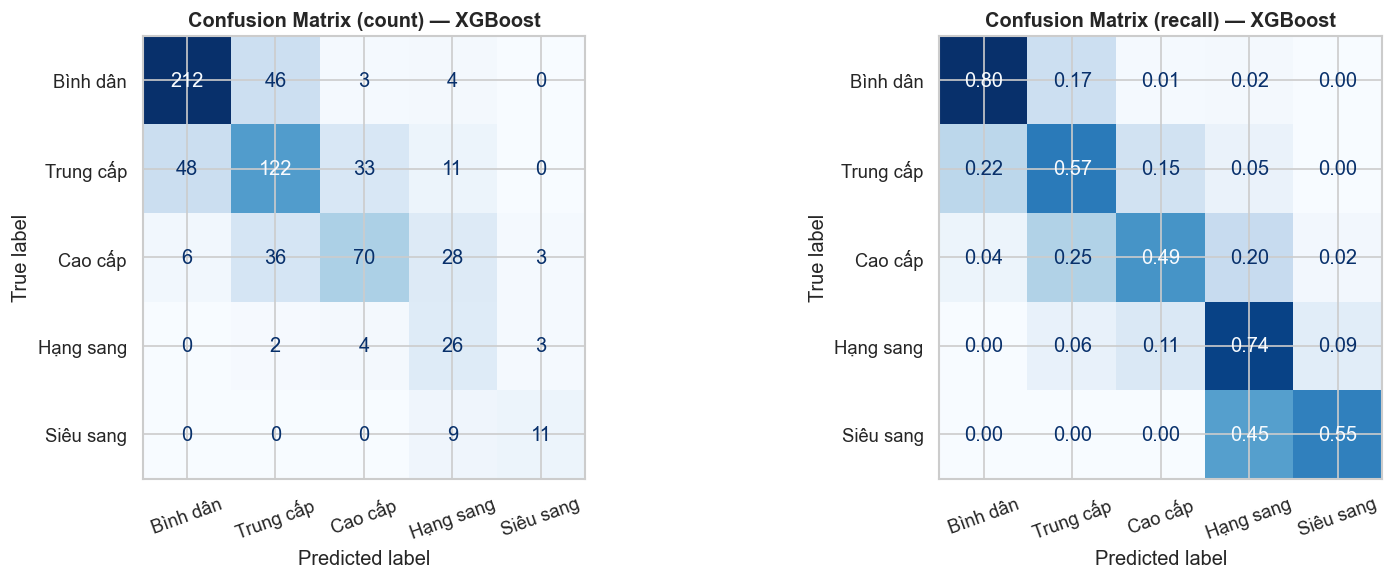

📊 Đã lưu: confusion_matrix.png


In [17]:
# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test_enc, y_pred, labels=list(range(len(LABELS))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion matrix (số tuyệt đối)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title(f'Confusion Matrix (count) — {BEST}', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# 2. Confusion matrix (chuẩn hóa theo hàng — recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=LABELS)
disp2.plot(ax=axes[1], cmap='Blues', values_format='.2f', colorbar=False)
axes[1].set_title(f'Confusion Matrix (recall) — {BEST}', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', bbox_inches='tight')
plt.show()
print('📊 Đã lưu: confusion_matrix.png')

## 8 · Feature Importance

Top 15 đặc trưng quan trọng nhất:


,Đặc trưng,Importance
0,Quận_encoded,0.1538
1,hem_xe_hoi,0.1417
2,Số tầng,0.0931
3,Diện tích,0.0644
4,Pháp lý_không có,0.0510
5,Đường vào,0.0504
6,Tổng số phòng,0.0473
7,gan_truong_hoc,0.0445
8,Loại đường vào,0.0441
9,duong_vao_null_flag,0.0418


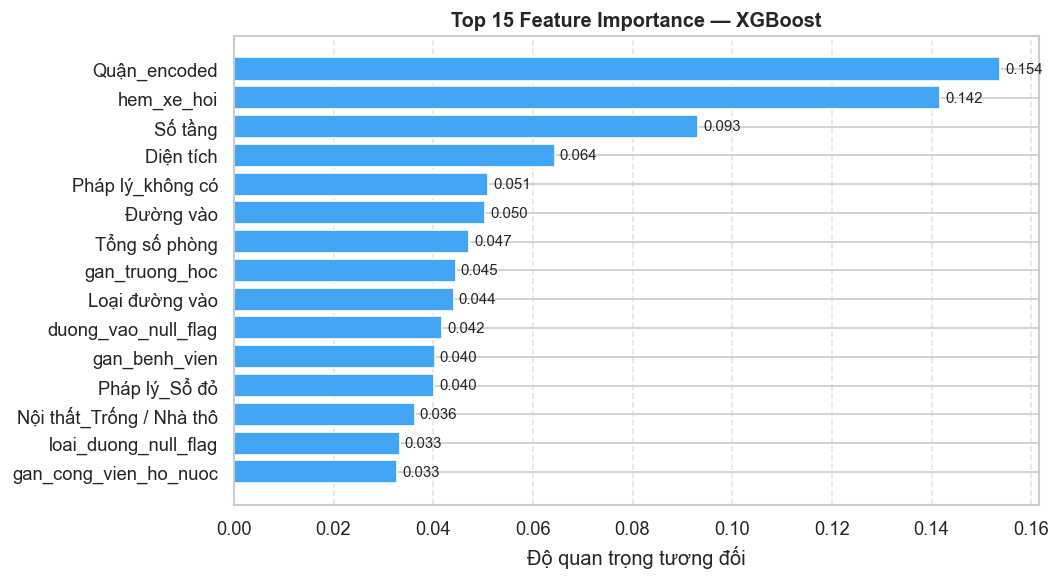

📊 Đã lưu: feature_importance.png


In [18]:
best_clf = best_pipe.named_steps['clf']

if hasattr(best_clf, 'feature_importances_'):
    imp_values = best_clf.feature_importances_
elif hasattr(best_clf, 'coef_'):
    imp_values = np.abs(best_clf.coef_).mean(axis=0)
else:
    imp_values = None
    print(f'ℹ️  {BEST} không hỗ trợ feature importance trực tiếp.')

if imp_values is not None:
    try:
        feat_names = best_pipe.named_steps['pre'].get_feature_names_out()
        feat_names = [re.sub(r'^(num|cat)__', '', n) for n in feat_names]
    except Exception:
        feat_names = [f'feat_{i}' for i in range(len(imp_values))]

    fi_df = (
        pd.DataFrame({'Đặc trưng': feat_names, 'Importance': imp_values})
        .sort_values('Importance', ascending=False)
        .reset_index(drop=True)
    )

    print('Top 15 đặc trưng quan trọng nhất:')
    display(fi_df.head(15).style.format({'Importance': '{:.4f}'})
                                .bar(subset=['Importance'], color='#90CAF9'))

    top = fi_df.head(15).sort_values('Importance')
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(top['Đặc trưng'], top['Importance'],
                   color='#42A5F5', edgecolor='white')
    ax.bar_label(bars, fmt='{:.3f}', padding=3, fontsize=9)
    ax.set_title(f'Top 15 Feature Importance — {BEST}',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Độ quan trọng tương đối')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'feature_importance.png', bbox_inches='tight')
    plt.show()
    print('📊 Đã lưu: feature_importance.png')

## 9 · Lưu Pipeline & Kết quả

In [19]:
# ── Lưu pipeline ──────────────────────────────────────────────────────────
model_filename = f'best_pipeline_{BEST.replace(" ", "_")}.pkl'
joblib.dump(best_pipe, OUTPUT_DIR / model_filename)
print(f'✅ Pipeline đã lưu: {model_filename}')

# ── Lưu encoded labels ────────────────────────────────────────────────────
y_train_enc.to_csv(OUTPUT_DIR / 'y_train_encoded.csv', header=True)
y_test_enc.to_csv(OUTPUT_DIR  / 'y_test_encoded.csv',  header=True)
X_train_model.to_csv(OUTPUT_DIR / 'X_train_model.csv')
X_test_model.to_csv(OUTPUT_DIR  / 'X_test_model.csv')

# ── Lưu bảng CV summary ───────────────────────────────────────────────────
cv_df.drop(columns=[c for c in cv_df.columns if c.startswith('_')], errors='ignore') \
     .to_csv(OUTPUT_DIR / 'cv_results.csv', index=False)

print(f'\n📁 Tất cả file đã lưu vào: {OUTPUT_DIR}')
print('\nDanh sách file:')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'   {f.name}')

✅ Pipeline đã lưu: best_pipeline_XGBoost.pkl

📁 Tất cả file đã lưu vào: c:\Users\ADMIN\Tien_xu_ly_du_lieu_BDS\data\Processed\ModelReady

Danh sách file:
   best_pipeline_Random_Forest.pkl
   best_pipeline_XGBoost.pkl
   class_distribution.png
   confusion_matrix.png
   cv_macro_f1_boxplot.png
   cv_results.csv
   feature_importance.png
   X_test_model.csv
   X_train_model.csv
   y_test_encoded.csv
   y_train_encoded.csv


## 10 · Kết luận Tổng hợp

### 10.1 · Tóm tắt pipeline

In [20]:
print('=' * 60)
print('TỔNG KẾT DỰ ÁN: PHÂN LOẠI PHÂN KHÚC GIÁ BẤT ĐỘNG SẢN')
print('=' * 60)

print('\n📋 BÀI TOÁN')
print(f'   Input  : {X_train_model.shape[1]} đặc trưng từ ~{len(X_train_model):,} bất động sản TP.HCM')
print(f'   Output : 5 phân khúc giá (Bình dân → Siêu sang)')

print('\n📊 KẾT QUẢ SO SÁNH MÔ HÌNH (Cross-Validation k=5):')
for _, row in cv_df.iterrows():
    marker = '🏆' if row['Mô hình'] == BEST else '  '
    print(f'   {marker} {row["Mô hình"]:<22}  '
          f'Macro F1 = {row["Macro F1 (mean)"]:.4f} ± {row["Macro F1 (std)"]:.4f}')

print(f'\n🎯 MÔ HÌNH TỐT NHẤT: {BEST}')
print(f'   Macro F1 (CV)   : {best_cv_row["Macro F1 (mean)"]:.4f} ± {best_cv_row["Macro F1 (std)"]:.4f}')
print(f'   Accuracy (Test) : {test_acc:.4f}')
print(f'   Macro F1 (Test) : {test_mf1:.4f}')
print(f'   Weighted F1     : {test_wf1:.4f}')

if imp_values is not None:
    top3 = fi_df.head(3)['Đặc trưng'].tolist()
    print(f'\n🔑 TOP 3 ĐẶC TRƯNG QUAN TRỌNG NHẤT:')
    for i, feat in enumerate(top3, 1):
        importance = fi_df.loc[fi_df['Đặc trưng'] == feat, 'Importance'].values[0]
        print(f'   {i}. {feat} (importance = {importance:.4f})')

TỔNG KẾT DỰ ÁN: PHÂN LOẠI PHÂN KHÚC GIÁ BẤT ĐỘNG SẢN

📋 BÀI TOÁN
   Input  : 18 đặc trưng từ ~2,822 bất động sản TP.HCM
   Output : 5 phân khúc giá (Bình dân → Siêu sang)

📊 KẾT QUẢ SO SÁNH MÔ HÌNH (Cross-Validation k=5):
   🏆 XGBoost                 Macro F1 = 0.5909 ± 0.0221
      Random Forest           Macro F1 = 0.5559 ± 0.0169
      SVM RBF                 Macro F1 = 0.5149 ± 0.0184
      Logistic Regression     Macro F1 = 0.4808 ± 0.0259
      Extra Trees             Macro F1 = 0.4732 ± 0.0137

🎯 MÔ HÌNH TỐT NHẤT: XGBoost
   Macro F1 (CV)   : 0.5909 ± 0.0221
   Accuracy (Test) : 0.6514
   Macro F1 (Test) : 0.5975
   Weighted F1     : 0.6544

🔑 TOP 3 ĐẶC TRƯNG QUAN TRỌNG NHẤT:
   1. Quận_encoded (importance = 0.1538)
   2. hem_xe_hoi (importance = 0.1417)
   3. Số tầng (importance = 0.0931)
